# Portfolio Workflow

This notebook runs one selected input workbook at a time. Change `SELECTED_CASE` in the setup cell to run another APF/APL, horizon, or benchmark setting.

In [1]:
import os
import sys
import subprocess
import importlib.util
from pathlib import Path

REPO_URL = "https://github.com/IvoEconometrics/asset-optimizer.git"
IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    PROJECT_ROOT = Path("/content/asset-optimizer")
    if not PROJECT_ROOT.exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(PROJECT_ROOT)])
    os.chdir(PROJECT_ROOT)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", ".[notebook]"])
else:
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT))

import cvxpy as cp
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from openpyxl import load_workbook

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)

from configs.ultimo_2025_colab import SCENARIO_CONFIG
from asset_optimizer.loader import load_scenario_set
from asset_optimizer.template import load_input_template, write_output_workbook
from asset_optimizer.stats import asset_summary, evaluate_portfolio, mean_neg_excess, pct_neg_excess, yearly_stats
from asset_optimizer.solver import Solver


## 1. Select Case

In [24]:
SELECTED_CASE = "APF_h15_no_inflation"

CASE_SPECS = {
    "APF_h5_no_inflation": {
        "label": "APF - 5 jaar zonder inflatie",
        "input_path": PROJECT_ROOT / "inputs" / "portfolio_input_APF_h5_no_inflation.xlsx",
        "output_path": PROJECT_ROOT / "outputs" / "portfolio_output_APF_h5_no_inflation.xlsx",
    },
    "APF_h5_inflation": {
        "label": "APF - 5 jaar met inflatie",
        "input_path": PROJECT_ROOT / "inputs" / "portfolio_input_APF_h5_inflation.xlsx",
        "output_path": PROJECT_ROOT / "outputs" / "portfolio_output_APF_h5_inflation.xlsx",
    },
    "APF_h15_no_inflation": {
        "label": "APF - 15 jaar zonder inflatie",
        "input_path": PROJECT_ROOT / "inputs" / "portfolio_input_APF_h15_no_inflation.xlsx",
        "output_path": PROJECT_ROOT / "outputs" / "portfolio_output_APF_h15_no_inflation.xlsx",
    },
    "APF_h15_inflation": {
        "label": "APF - 15 jaar met inflatie",
        "input_path": PROJECT_ROOT / "inputs" / "portfolio_input_APF_h15_inflation.xlsx",
        "output_path": PROJECT_ROOT / "outputs" / "portfolio_output_APF_h15_inflation.xlsx",
    },
    "APL_h5_no_inflation": {
        "label": "APL - 5 jaar zonder inflatie",
        "input_path": PROJECT_ROOT / "inputs" / "portfolio_input_APL_h5_no_inflation.xlsx",
        "output_path": PROJECT_ROOT / "outputs" / "portfolio_output_APL_h5_no_inflation.xlsx",
    },
    "APL_h5_inflation": {
        "label": "APL - 5 jaar met inflatie",
        "input_path": PROJECT_ROOT / "inputs" / "portfolio_input_APL_h5_inflation.xlsx",
        "output_path": PROJECT_ROOT / "outputs" / "portfolio_output_APL_h5_inflation.xlsx",
    },
    "APL_h15_no_inflation": {
        "label": "APL - 15 jaar zonder inflatie",
        "input_path": PROJECT_ROOT / "inputs" / "portfolio_input_APL_h15_no_inflation.xlsx",
        "output_path": PROJECT_ROOT / "outputs" / "portfolio_output_APL_h15_no_inflation.xlsx",
    },
    "APL_h15_inflation": {
        "label": "APL - 15 jaar met inflatie",
        "input_path": PROJECT_ROOT / "inputs" / "portfolio_input_APL_h15_inflation.xlsx",
        "output_path": PROJECT_ROOT / "outputs" / "portfolio_output_APL_h15_inflation.xlsx",
    },
}

spec = CASE_SPECS[SELECTED_CASE]
print("Selected:", spec["label"])
print("Input:", spec["input_path"])
print("Output:", spec["output_path"])

Selected: APF - 15 jaar zonder inflatie
Input: /content/asset-optimizer/inputs/portfolio_input_APF_h15_no_inflation.xlsx
Output: /content/asset-optimizer/outputs/portfolio_output_APF_h15_no_inflation.xlsx


## 2. Load Scenario Data

In [12]:
scenario_set = load_scenario_set(SCENARIO_CONFIG, load_yields=False, load_bei=False)
print("Asset returns:", scenario_set.asset_returns.shape)
print("Yield curves loaded:", scenario_set.yields is not None)
asset_summary(scenario_set.asset_returns, scenario_set.asset_names).assign(
    Arith_Return=lambda df: df["Arith_Return"].map(lambda value: f"{value:.2%}"),
    Volatility=lambda df: df["Volatility"].map(lambda value: f"{value:.2%}"),
)


Asset returns: (2000, 30, 26)
Yield curves loaded: False


,Asset,Arith_Return,Volatility
0,Looninflatie NL,2.62%,2.22%
1,Prijsinflatie NL,2.22%,2.01%
2,Aandelen Opkomende Markten,11.65%,28.05%
3,Aandelen Wereld DC,7.43%,17.44%
4,Aandelen Wereld DC Unhedged,7.41%,19.81%
5,Bank Loans,5.39%,6.95%
6,Beursgenoteerd Vastgoed,7.96%,20.95%
7,Cash,2.66%,1.70%
8,Direct Lending Europa,6.42%,7.95%
9,Duitse Staatsobligaties,3.49%,5.77%


## 3. Load Input Workbook

In [25]:
inputs = load_input_template(spec["input_path"], scenario_set)
horizon_years = int(inputs["settings"].loc["horizon_years"])
matrix_h = scenario_set.asset_returns[:, :horizon_years, :]
benchmark_weights = inputs["benchmark"].reindex(scenario_set.asset_names).fillna(0.0).to_numpy(dtype=float)
benchmark_h = matrix_h @ benchmark_weights
selected_matrix = matrix_h - benchmark_h[:, :, None]

print("Horizon:", horizon_years)
print("Benchmark weight sum:", benchmark_weights.sum())
print("Portfolios:", inputs["portfolios"].shape)
print("Sheets:", load_workbook(spec["input_path"], read_only=True, data_only=True).sheetnames)

Horizon: 15
Benchmark weight sum: 0.0
Portfolios: (26, 10)
Sheets: ['uitleg', 'settings', 'benchmark', 'optimization', 'portfolios']


## 4. Evaluate Portfolios

In [26]:
mu, sigma = yearly_stats(selected_matrix)
portfolios = inputs["portfolios"].reindex(scenario_set.asset_names).fillna(0.0)

rows = []
for portfolio_name in portfolios.columns:
    weights = portfolios[portfolio_name].to_numpy(dtype=float)
    stats = evaluate_portfolio(
        selected_matrix,
        weights,
        rf=0.0,
        mu=mu,
        sigma=sigma,
        benchmark_paths=benchmark_h,
        raw_matrix=matrix_h,
    )
    rows.append({"Portfolio": portfolio_name, "Weight_Sum": weights.sum(), **stats})

portfolio_stats = pd.DataFrame(rows)
portfolio_stats_display = portfolio_stats.copy()
for column in ["Weight_Sum", "Arith_Return", "Geo_Return", "Volatility", "Compound_Vol", "Mean_Neg_Excess_Overall"]:
    if column in portfolio_stats_display:
        portfolio_stats_display[column] = portfolio_stats_display[column].map(lambda value: f"{value:.2%}")
for column in ["Pct_Pos_Return", "Pct_Neg_Excess_Terminal", "Pct_Neg_Excess_Overall"]:
    if column in portfolio_stats_display:
        portfolio_stats_display[column] = portfolio_stats_display[column].map(lambda value: f"{value / 100.0:.2%}")
portfolio_stats_display["Sharpe"] = portfolio_stats_display["Sharpe"].map(lambda value: f"{value:.2f}")
portfolio_stats_display

,Portfolio,Weight_Sum,Arith_Return,Geo_Return,Volatility,Compound_Vol,Sharpe,Pct_Pos_Return,Pct_Neg_Excess_Terminal,Pct_Neg_Excess_Overall,Mean_Neg_Excess_Overall
0,Module Rendement,100.00%,6.24%,5.65%,11.17%,2.53%,0.51,71.41%,1.35%,28.59%,-7.38%
1,HF naar Aandelen,100.00%,6.39%,5.57%,12.99%,2.92%,0.43,69.24%,3.15%,30.76%,-8.84%
2,HF naar rato,99.90%,6.30%,5.55%,12.46%,2.77%,0.45,69.74%,2.75%,30.26%,-8.44%
3,HF naar Aandelen en VG,100.00%,6.31%,5.57%,12.39%,2.78%,0.45,69.83%,2.75%,30.17%,-8.38%
4,HF naar Aandelen wereld,100.00%,6.29%,5.49%,12.91%,2.92%,0.43,69.16%,3.20%,30.84%,-8.83%
5,HF naar Vastgoed,100.00%,6.23%,5.56%,11.87%,2.66%,0.47,70.36%,2.20%,29.64%,-7.99%
6,HDP,100.00%,6.45%,5.89%,10.86%,2.57%,0.54,72.32%,1.15%,27.68%,-7.04%
7,HF naar private debt,100.00%,6.29%,5.62%,11.74%,2.59%,0.48,70.95%,1.50%,29.05%,-7.93%
8,HF naar bank loans,100.00%,6.19%,5.54%,11.63%,2.55%,0.48,70.79%,1.55%,29.21%,-7.82%
9,HF naar infrastructuur,100.00%,6.34%,5.66%,11.84%,2.67%,0.48,70.80%,1.80%,29.20%,-8.00%


## 5. Solve Frontier

In [27]:
bounds = inputs["asset_bounds"].reindex(scenario_set.asset_names)
lb = bounds["Min"].fillna(0.0).to_numpy(dtype=float)
ub = bounds["Max"].fillna(1.0).to_numpy(dtype=float)

group_bounds = inputs["group_bounds"]
active_groups = group_bounds[group_bounds[["Min", "Max"]].notna().any(axis=1)]
if active_groups.empty:
    group_A = group_lb = group_ub = None
else:
    memberships = inputs["group_memberships"].reindex(scenario_set.asset_names)
    group_keys = list(active_groups.index)
    group_A = memberships[group_keys].apply(pd.to_numeric, errors="coerce").fillna(0.0).T.to_numpy(dtype=float)
    group_lb = active_groups["Min"].fillna(0.0).to_numpy(dtype=float)
    group_ub = active_groups["Max"].fillna(1.0).to_numpy(dtype=float)

solver = Solver(
    mu,
    sigma,
    lb,
    ub,
    scenario_set.asset_names,
    group_A=group_A,
    group_lb=group_lb,
    group_ub=group_ub,
    solver=cp.GUROBI,
)
frontier = solver.solve_frontier(
    n_lambdas=int(inputs["settings"].get("frontier_points", 25)),
    step=float(inputs["settings"].get("step_size", 0.025)),
)
frontier_weights = frontier[scenario_set.asset_names].to_numpy(dtype=float)
frontier["Pct_Neg_Excess_Terminal"], frontier["Pct_Neg_Excess_Overall"] = pct_neg_excess(frontier_weights, benchmark_h, matrix_h)
frontier["Mean_Neg_Excess_Overall"] = mean_neg_excess(frontier_weights, benchmark_h, matrix_h)

frontier_metric_rows = []
for idx, weights in enumerate(frontier_weights, start=1):
    metrics = evaluate_portfolio(
        selected_matrix,
        weights,
        rf=0.0,
        mu=mu,
        sigma=sigma,
        benchmark_paths=benchmark_h,
        raw_matrix=matrix_h,
    )
    frontier_metric_rows.append({"Portfolio": f"Frontier {idx}", "Weight_Sum": weights.sum(), **metrics})
frontier_metrics = pd.DataFrame(frontier_metric_rows).set_index("Portfolio")
for metric in frontier_metrics.columns:
    frontier[metric] = frontier_metrics[metric].to_numpy(dtype=float)

print("Frontier rows:", len(frontier))
frontier[["Arith_Return", "Volatility"]].head()


Frontier rows: 25


,Arith_Return,Volatility
0,0.026055,0.010814
1,0.026184,0.010822
2,0.027255,0.010958
3,0.028908,0.011262
4,0.029037,0.011299


## 6. Plot Frontier

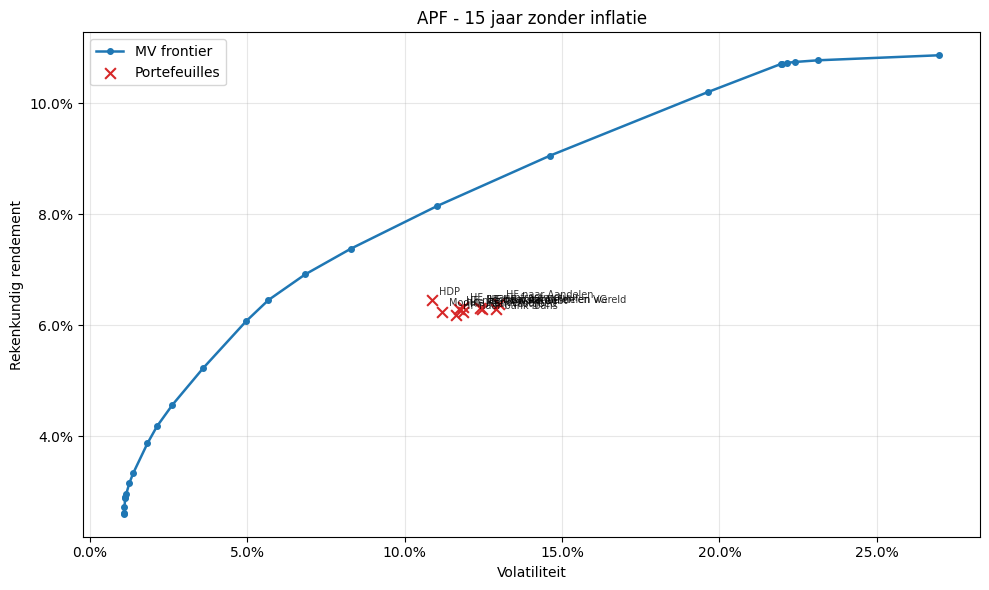

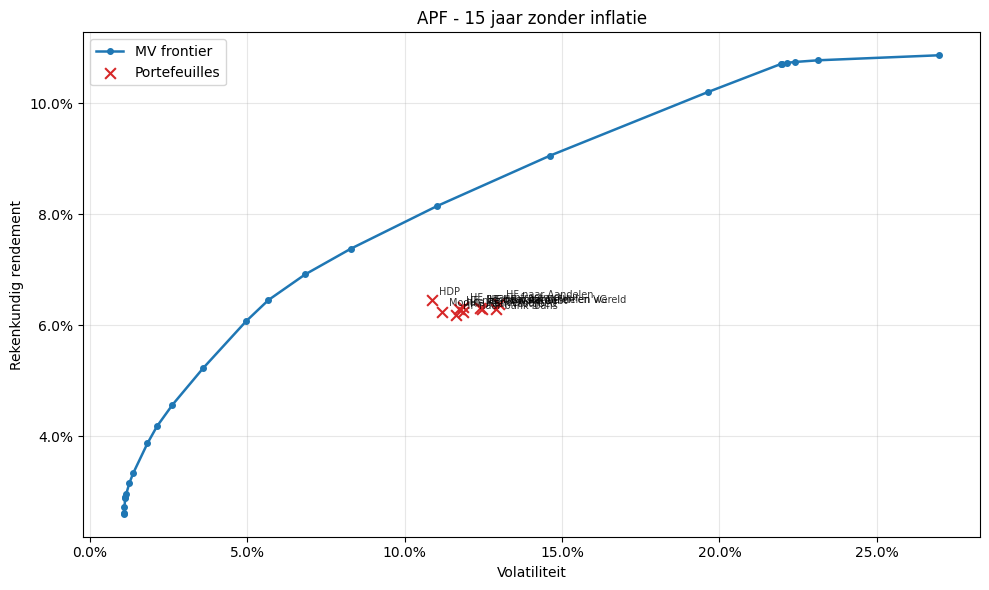

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frontier["Volatility"], frontier["Arith_Return"], marker="o", markersize=4, linewidth=1.8, label="MV frontier")
ax.scatter(portfolio_stats["Volatility"], portfolio_stats["Arith_Return"], marker="x", s=60, color="#d62728", label="Portefeuilles")
for _, row in portfolio_stats.iterrows():
    ax.annotate(row["Portfolio"], (row["Volatility"], row["Arith_Return"]), xytext=(5, 4), textcoords="offset points", fontsize=7, alpha=0.8)
ax.set_title(spec["label"])
ax.set_xlabel("Volatiliteit")
ax.set_ylabel("Rekenkundig rendement")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
fig

## 7. Write Output Workbook

In [29]:
write_output_workbook(
    input_path=spec["input_path"],
    output_path=spec["output_path"],
    portfolios=portfolios,
    portfolio_stats=portfolio_stats,
    frontier=frontier,
)
print("Wrote:", spec["output_path"])
print("Output sheets:", load_workbook(spec["output_path"], read_only=True, data_only=True).sheetnames)
spec["output_path"]

Wrote: /content/asset-optimizer/outputs/portfolio_output_APF_h15_no_inflation.xlsx
Output sheets: ['uitleg', 'settings', 'benchmark', 'optimization', 'portfolios', 'output']


PosixPath('/content/asset-optimizer/outputs/portfolio_output_APF_h15_no_inflation.xlsx')